In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [6]:
data=pd.read_csv("Data/CED.csv")
data

,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score,calorie_efficiency
0,51,7853,99,1500,6.42,3.60,22.34,3,0.321,0.050,68.5,102.0,1,0.603,Low Efficiency
1,60,4820,78,1500,6.82,4.18,32.30,6,0.548,0.200,72.5,121.2,3,0.958,Low Efficiency
2,59,4251,28,1500,6.99,2.95,24.71,2,0.245,0.390,75.4,120.4,1,0.987,Low Efficiency
3,39,6275,75,1500,6.65,2.62,28.80,1,0.389,0.197,65.8,114.8,1,0.711,Low Efficiency
4,22,6490,82,1500,5.80,0.97,21.92,2,0.326,0.325,71.9,116.2,6,0.551,Low Efficiency
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999995,55,5881,81,1500,4.06,1.91,25.66,5,0.322,0.101,70.0,110.8,2,0.387,Low Efficiency
999996,53,3303,41,1500,6.65,1.58,26.21,1,0.200,0.329,67.4,111.3,1,1.393,Low Efficiency
999997,28,8553,62,1500,5.33,3.86,20.70,4,0.426,0.339,61.4,119.0,1,0.515,Low Efficiency
999998,34,6936,52,1500,8.52,1.58,21.95,7,0.251,0.332,64.9,107.0,2,0.595,Low Efficiency


In [24]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 14 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   age                       1000000 non-null  int64  
 1   steps_per_day             1000000 non-null  int64  
 2   active_minutes            1000000 non-null  int64  
 3   calories_burned           1000000 non-null  int64  
 4   sleep_hours               1000000 non-null  float64
 5   hydration_liters          1000000 non-null  float64
 6   bmi                       1000000 non-null  float64
 7   workouts_per_week         1000000 non-null  int64  
 8   muscle_mass_ratio         1000000 non-null  float64
 9   body_fat_percentage       1000000 non-null  float64
 10  heart_rate_resting        1000000 non-null  float64
 11  heart_rate_avg            1000000 non-null  float64
 12  continuous_exercise_days  1000000 non-null  int64  
 13  efficiency_score          10

In [7]:
data = data.drop(['calorie_efficiency'], axis=1)
data.head()

,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score
0,51,7853,99,1500,6.42,3.60,22.34,3,0.321,0.050,68.5,102.0,1,0.603
1,60,4820,78,1500,6.82,4.18,32.30,6,0.548,0.200,72.5,121.2,3,0.958
2,59,4251,28,1500,6.99,2.95,24.71,2,0.245,0.390,75.4,120.4,1,0.987
3,39,6275,75,1500,6.65,2.62,28.80,1,0.389,0.197,65.8,114.8,1,0.711
4,22,6490,82,1500,5.80,0.97,21.92,2,0.326,0.325,71.9,116.2,6,0.551


In [15]:
data.corr()

,age,steps_per_day,active_minutes,calories_burned,sleep_hours,hydration_liters,bmi,workouts_per_week,muscle_mass_ratio,body_fat_percentage,heart_rate_resting,heart_rate_avg,continuous_exercise_days,efficiency_score
age,1.000000,0.000489,-0.000571,NaN,-0.001330,0.000850,-0.001014,0.000888,0.001107,-0.002178,-0.000612,-0.000139,0.000209,0.000648
steps_per_day,0.000489,1.000000,0.855691,NaN,0.000958,0.000101,-0.844215,-0.001614,0.000146,0.000271,-0.855566,-0.427176,-0.000170,-0.680543
active_minutes,-0.000571,0.855691,1.000000,NaN,0.000646,0.000274,-0.722214,-0.001687,-0.000237,-0.000157,-0.732351,-0.365667,0.000160,-0.612025
calories_burned,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours,-0.001330,0.000958,0.000646,NaN,1.000000,0.001526,-0.000662,0.000487,-0.000689,-0.001045,-0.000427,-0.000365,0.000173,0.175006
hydration_liters,0.000850,0.000101,0.000274,NaN,0.001526,1.000000,0.000053,0.000130,-0.000051,-0.002320,0.000746,0.000051,0.000085,0.068051
bmi,-0.001014,-0.844215,-0.722214,NaN,-0.000662,0.000053,1.000000,0.001634,0.001270,-0.000556,0.723026,0.360989,0.000005,0.601072
workouts_per_week,0.000888,-0.001614,-0.001687,NaN,0.000487,0.000130,0.001634,1.000000,0.000225,0.001955,0.000326,-0.000625,-0.001256,-0.023231
muscle_mass_ratio,0.001107,0.000146,-0.000237,NaN,-0.000689,-0.000051,0.001270,0.000225,1.000000,-0.000193,-0.000417,-0.000327,0.000499,0.040073
body_fat_percentage,-0.002178,0.000271,-0.000157,NaN,-0.001045,-0.002320,-0.000556,0.001955,-0.000193,1.000000,-0.000096,0.001144,0.001022,-0.039098


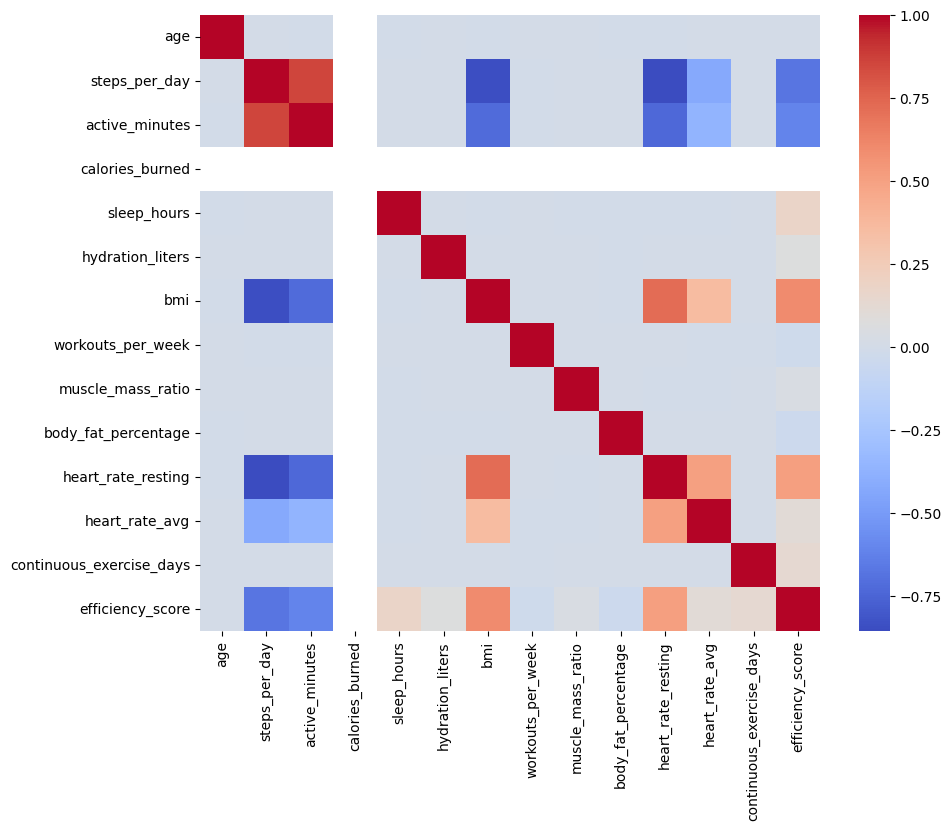

In [11]:
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.show()

### Data splitting

In [16]:
X=data.drop(['steps_per_day', 'active_minutes','calories_burned','efficiency_score'], axis=1)
y=data['efficiency_score']

In [18]:
from sklearn.model_selection import train_test_split
trainx, testx, trainy, testy = train_test_split(X, y, test_size=0.3, random_state=42)

### Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
trainx = scaler.fit_transform(trainx)
testx = scaler.transform(testx)

In [61]:
import pickle
pickle.dump(scaler,open("scaler.pkl","wb"))

In [21]:
trainx

array([[ 1.25528056,  0.55162942,  0.39987303, ..., -1.98793498,
        -0.81736651, -0.25638585],
       [ 1.6242757 ,  0.80248291, -0.84620385, ...,  1.36557874,
         0.78398717, -0.25638585],
       [ 0.96008445, -1.06219467, -0.93431029, ..., -2.00522113,
        -1.8936862 , -0.25638585],
       ...,
       [ 0.73868737, -1.0956418 , -0.24204536, ...,  0.22469263,
         1.17776267,  2.70876807],
       [ 1.18148153,  1.07842174, -0.78327067, ..., -1.52120884,
        -1.473659  , -0.25638585],
       [-1.03248931, -0.0253336 ,  0.51315274, ...,  0.27655109,
        -0.48484498, -0.25638585]])

### Model training 

In [22]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(trainx, trainy)

LinearRegression()

In [25]:
print(model.coef_)
print(model.intercept_)

[ 0.00104761  0.10960174  0.04190354  0.30292299 -0.01511625  0.02481514
 -0.02352108  0.16590328 -0.12785579  0.08265007]
0.8786339485714274


In [26]:
predicted=model.predict(testx)
print(predicted)

[1.32140591 1.3149192  0.7986788  ... 1.42977246 1.02550369 1.43829108]


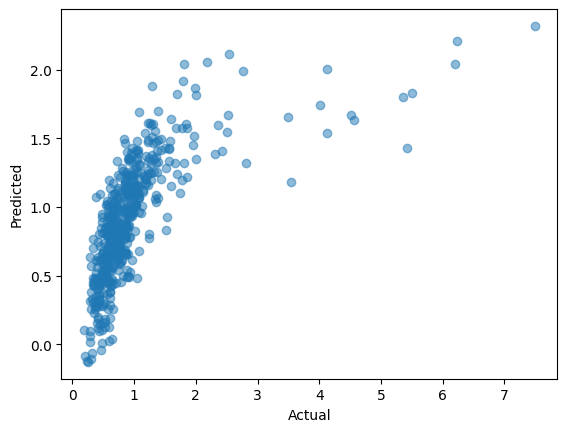

In [35]:
plt.scatter(testy[:500], predicted[:500], alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()  

In [37]:
residuals=testy-predicted
residuals

987231    0.027594
79954    -0.237919
567130    0.069321
500891    0.640181
55399    -0.330573
            ...   
463299   -0.194067
728324    0.273986
76260    -0.488772
77813    -0.525504
718205    0.257709
Name: efficiency_score, Length: 300000, dtype: float64

In [38]:
from sklearn.metrics import mean_squared_error, r2_score
mse = mean_squared_error(testy, predicted)
r2 = r2_score(testy, predicted)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)

Mean Squared Error: 0.20752619930797983
R2 Score: 0.46116737314506573


In [59]:
newtest=trainx[5000]
newtest=newtest.reshape(1,-1)
newy=model.predict(newtest)
newy[0]

0.21663439322124056

### Pickling the model 

In [60]:
import pickle
pickle.dump(model, open('model.pkl', 'wb'))
print("Model saved successfully")

Model saved successfully
